# Phase 4: U-Net Model Setup and Training

Trains a U-Net with a pre-trained encoder to segment flooded pixels from the Sentinel-1 patches made by `data/data_preprocessing.ipynb`.

**Before running:**
- `dataset_patches/` (with `train/`, `val/`, `test/` and `dataset_info.json`) must be on this runtime. Run `data_preprocessing.ipynb` in the same Colab session, or upload the folder.
- Use a GPU runtime (Runtime > Change runtime type > GPU). It runs on CPU, but slowly.

In [1]:
# Cell 1: Install dependencies
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.4 MB/s eta 0:00:00


In [2]:
import os
import glob
import json
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# -------------------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------------------
DATA_DIR = 'dataset_patches'
CHECKPOINT_PATH = 'unet_best.pt'

ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'  # Pre-trained encoder weights
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5               # Probability above which a pixel is called flooded
NUM_WORKERS = 2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Settings recorded by the preprocessing notebook (input bands, normalisation statistics)
with open(os.path.join(DATA_DIR, 'dataset_info.json')) as f:
    dataset_info = json.load(f)

IN_CHANNELS = len(dataset_info['input_bands'])
print(f"Input channels ({IN_CHANNELS}): {dataset_info['input_bands']}")

Using device: cuda
Input channels (4): ['pre_vv', 'pre_vh', 'post_vv', 'post_vh']


In [3]:
# -------------------------------------------------------------------------
# 2. Dataset & DataLoaders
# -------------------------------------------------------------------------
class FloodPatchDataset(Dataset):
    """Image/mask patch pairs saved by data_preprocessing.ipynb.

    Images are float32 (C, 256, 256) and already normalised; masks are uint8 (256, 256).
    """

    def __init__(self, data_dir, split, augment=False):
        self.image_paths = sorted(glob.glob(os.path.join(data_dir, split, 'images', '*.npy')))
        self.mask_paths = sorted(glob.glob(os.path.join(data_dir, split, 'masks', '*.npy')))
        if not self.image_paths:
            raise FileNotFoundError(f"No patches found in '{os.path.join(data_dir, split)}' - "
                                    "run data_preprocessing.ipynb on this runtime first.")
        image_names = [os.path.basename(p) for p in self.image_paths]
        mask_names = [os.path.basename(p) for p in self.mask_paths]
        if image_names != mask_names:
            raise ValueError(f"Images and masks do not match in the '{split}' split.")
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx])       # (C, H, W)
        mask = np.load(self.mask_paths[idx])[None]   # (1, H, W)

        # Flips and 90-degree rotations, applied identically to image and mask
        if self.augment:
            if random.random() < 0.5:
                image, mask = image[:, :, ::-1], mask[:, :, ::-1]
            if random.random() < 0.5:
                image, mask = image[:, ::-1, :], mask[:, ::-1, :]
            k = random.randint(0, 3)
            image, mask = np.rot90(image, k, axes=(1, 2)), np.rot90(mask, k, axes=(1, 2))

        image = torch.from_numpy(np.ascontiguousarray(image)).float()
        mask = torch.from_numpy(np.ascontiguousarray(mask)).float()
        return image, mask


train_dataset = FloodPatchDataset(DATA_DIR, 'train', augment=True)
val_dataset = FloodPatchDataset(DATA_DIR, 'val')
test_dataset = FloodPatchDataset(DATA_DIR, 'test')

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_args)

print(f"Train Patches: {len(train_dataset)}")
print(f"Val Patches  : {len(val_dataset)}")
print(f"Test Patches : {len(test_dataset)}")

images, masks = next(iter(train_loader))
print(f"Batch shapes : images {tuple(images.shape)}, masks {tuple(masks.shape)}")
print(f"Flooded pixels in this batch: {100 * masks.mean().item():.2f}%")

Train Patches: 623
Val Patches  : 141
Test Patches : 129
Batch shapes : images (16, 4, 256, 256), masks (16, 1, 256, 256)
Flooded pixels in this batch: 0.29%


In [4]:
# -------------------------------------------------------------------------
# 3. Pre-trained U-Net
# -------------------------------------------------------------------------
# The encoder starts from ImageNet weights; smp adapts its first layer from 3 to
# IN_CHANNELS inputs. The model outputs one logit per pixel (apply sigmoid for probability).
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=1,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net with {ENCODER} encoder: {n_params / 1e6:.1f}M parameters")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

U-Net with resnet34 encoder: 24.4M parameters


In [5]:
# -------------------------------------------------------------------------
# 4. Loss (BCE + Dice) & Metrics
# -------------------------------------------------------------------------
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)

def criterion(logits, masks):
    return bce_loss(logits, masks) + dice_loss(logits, masks)

def flood_metrics(tp, fp, fn):
    """Metrics for the flooded class, from pixel counts over a whole split."""
    eps = 1e-7
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        'iou': tp / (tp + fp + fn + eps),
        'precision': precision,
        'recall': recall,
        'f1': 2 * precision * recall / (precision + recall + eps),
    }

In [6]:
# -------------------------------------------------------------------------
# 5. Training Loop
# -------------------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler(device.type, enabled=use_amp)

def run_epoch(loader, train):
    model.train(train)
    total_loss, tp, fp, fn = 0.0, 0, 0, 0

    with torch.set_grad_enabled(train):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
            loss = criterion(logits.float(), masks)  # Loss in full precision

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(logits) > THRESHOLD
            truth = masks > 0.5
            tp += (preds & truth).sum().item()
            fp += (preds & ~truth).sum().item()
            fn += (~preds & truth).sum().item()

    return {'loss': total_loss / len(loader.dataset), **flood_metrics(tp, fp, fn)}


history = []
best_val_iou = -1.0

for epoch in range(1, EPOCHS + 1):
    train_stats = run_epoch(train_loader, train=True)
    val_stats = run_epoch(val_loader, train=False)
    history.append({'epoch': epoch, 'train': train_stats, 'val': val_stats})

    saved = ''
    if val_stats['iou'] > best_val_iou:
        best_val_iou = val_stats['iou']
        torch.save({
            'model_state': model.state_dict(),
            'encoder': ENCODER,
            'in_channels': IN_CHANNELS,
            'input_bands': dataset_info['input_bands'],
            'normalisation': dataset_info['normalisation'],
            'threshold': THRESHOLD,
            'epoch': epoch,
            'val_iou': best_val_iou,
        }, CHECKPOINT_PATH)
        saved = '  <- saved'

    print(f"Epoch {epoch:3d}/{EPOCHS} | train loss {train_stats['loss']:.4f} IoU {train_stats['iou']:.3f} | "
          f"val loss {val_stats['loss']:.4f} IoU {val_stats['iou']:.3f} "
          f"P {val_stats['precision']:.3f} R {val_stats['recall']:.3f}{saved}")

print(f"\nBest validation IoU: {best_val_iou:.3f} (checkpoint: '{CHECKPOINT_PATH}')")

Epoch   1/40 | train loss 1.6552 IoU 0.036 | val loss 1.6225 IoU 0.045 P 0.045 R 0.837  <- saved
Epoch   2/40 | train loss 1.4216 IoU 0.088 | val loss 1.4411 IoU 0.081 P 0.083 R 0.840  <- saved
Epoch   3/40 | train loss 1.3517 IoU 0.158 | val loss 1.3697 IoU 0.143 P 0.146 R 0.868  <- saved
Epoch   4/40 | train loss 1.2981 IoU 0.279 | val loss 1.3482 IoU 0.257 P 0.279 R 0.770  <- saved
Epoch   5/40 | train loss 1.2572 IoU 0.373 | val loss 1.2793 IoU 0.314 P 0.326 R 0.895  <- saved
Epoch   6/40 | train loss 1.2175 IoU 0.424 | val loss 1.2484 IoU 0.444 P 0.471 R 0.887  <- saved
Epoch   7/40 | train loss 1.1880 IoU 0.480 | val loss 1.2569 IoU 0.404 P 0.418 R 0.920
Epoch   8/40 | train loss 1.1561 IoU 0.510 | val loss 1.1819 IoU 0.507 P 0.552 R 0.859  <- saved
Epoch   9/40 | train loss 1.1246 IoU 0.564 | val loss 1.1836 IoU 0.434 P 0.450 R 0.928
Epoch  10/40 | train loss 1.1066 IoU 0.550 | val loss 1.1313 IoU 0.511 P 0.533 R 0.927  <- saved
Epoch  11/40 | train loss 1.0748 IoU 0.581 | val l

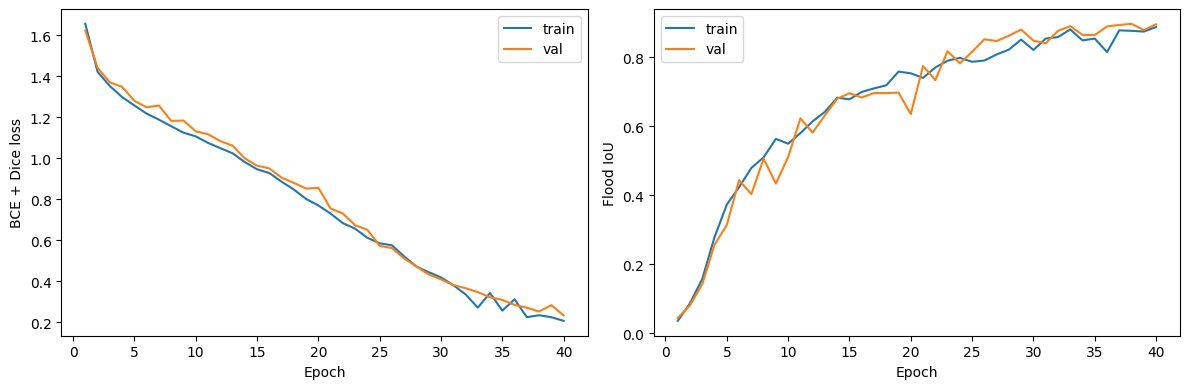

In [7]:
# -------------------------------------------------------------------------
# 6. Training Curves
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

epochs = [h['epoch'] for h in history]
fig, (ax_loss, ax_iou) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(epochs, [h['train']['loss'] for h in history], label='train')
ax_loss.plot(epochs, [h['val']['loss'] for h in history], label='val')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('BCE + Dice loss')
ax_loss.legend()

ax_iou.plot(epochs, [h['train']['iou'] for h in history], label='train')
ax_iou.plot(epochs, [h['val']['iou'] for h in history], label='val')
ax_iou.set_xlabel('Epoch')
ax_iou.set_ylabel('Flood IoU')
ax_iou.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# -------------------------------------------------------------------------
# 7. Test Set Evaluation (best checkpoint)
# -------------------------------------------------------------------------
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} (val IoU {checkpoint['val_iou']:.3f})")

test_stats = run_epoch(test_loader, train=False)
print(f"Test loss     : {test_stats['loss']:.4f}")
print(f"Flood IoU     : {test_stats['iou']:.3f}")
print(f"Precision     : {test_stats['precision']:.3f}")
print(f"Recall        : {test_stats['recall']:.3f}")
print(f"F1 score      : {test_stats['f1']:.3f}")

Loaded checkpoint from epoch 38 (val IoU 0.897)
Test loss     : 0.4869
Flood IoU     : 0.927
Precision     : 0.955
Recall        : 0.969
F1 score      : 0.962


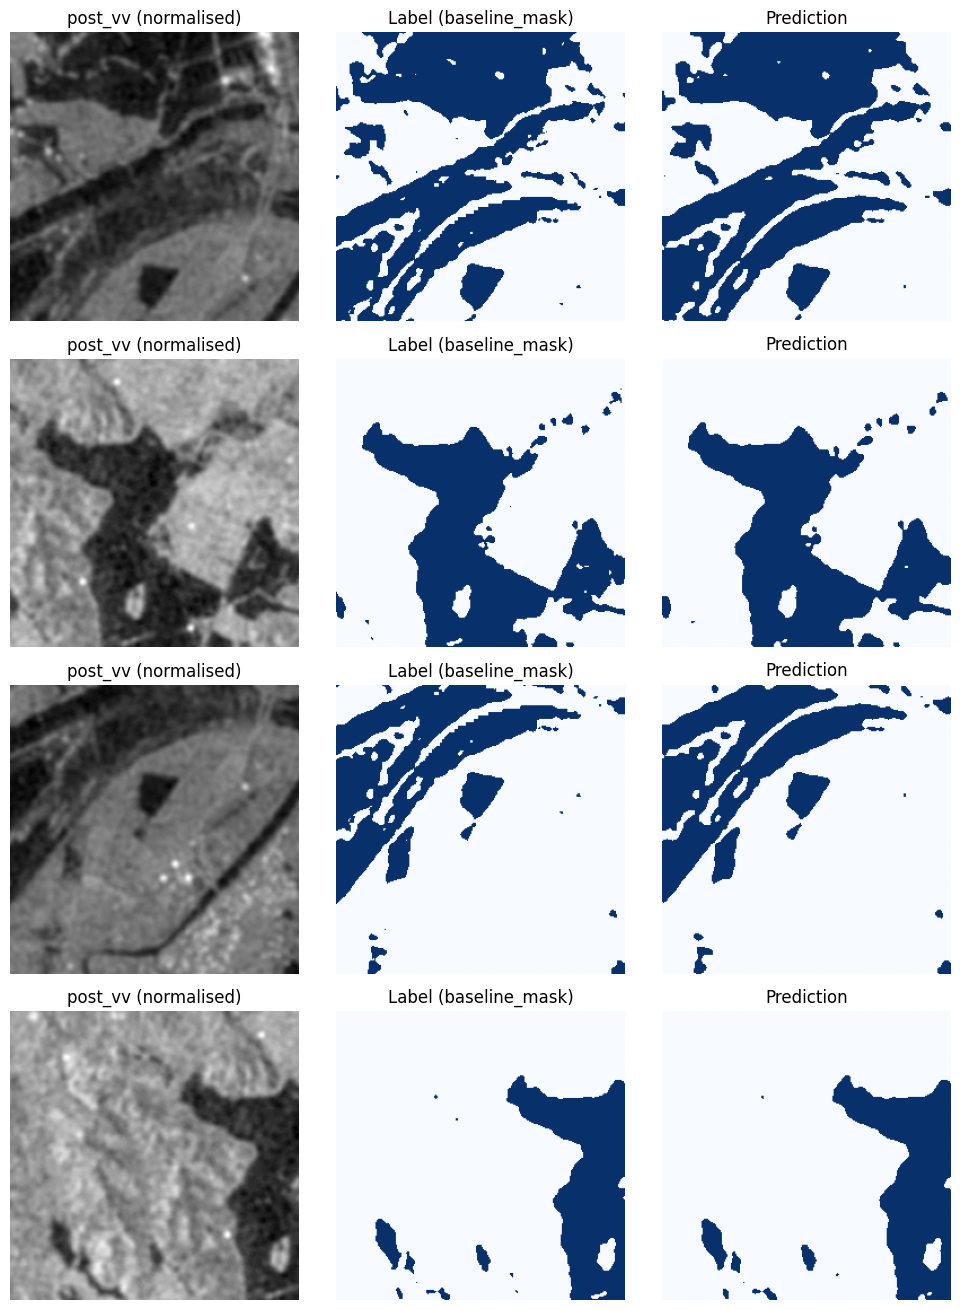

In [9]:
# -------------------------------------------------------------------------
# 8. Example Predictions (most-flooded test patches)
# -------------------------------------------------------------------------
N_EXAMPLES = 4
post_vv_idx = dataset_info['input_bands'].index('post_vv')

flood_counts = [np.load(p).sum() for p in test_dataset.mask_paths]
example_ids = np.argsort(flood_counts)[::-1][:N_EXAMPLES]

model.eval()
fig, axes = plt.subplots(N_EXAMPLES, 3, figsize=(10, 3.3 * N_EXAMPLES), squeeze=False)
for row, idx in enumerate(example_ids):
    image, mask = test_dataset[idx]
    with torch.no_grad():
        prob = torch.sigmoid(model(image[None].to(device)))[0, 0].cpu().numpy()

    axes[row, 0].imshow(image[post_vv_idx].numpy(), cmap='gray')
    axes[row, 0].set_title('post_vv (normalised)')
    axes[row, 1].imshow(mask[0].numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[row, 1].set_title('Label (baseline_mask)')
    axes[row, 2].imshow(prob > THRESHOLD, cmap='Blues', vmin=0, vmax=1)
    axes[row, 2].set_title('Prediction')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Notes

- **The checkpoint is on the Colab disk.** Download `unet_best.pt` (and the two PNGs) before the runtime resets. It stores the normalisation statistics, so the same values can be applied to a new scene at inference time.
- **What the score means.** The labels are a -3.5 dB threshold on the VV change, which the model can rebuild from its inputs. A high IoU here shows the U-Net reproduces that rule, not that it detects real flooding; that needs independent labels (e.g. the Copernicus EMS reference for Cyclone Idai).
- **Class imbalance.** About 1.4% of pixels are flooded, so judge the model on flood IoU, precision and recall rather than accuracy.